Notebook này sẽ tách **16 nhãn MBTI** thành **4 bài toán Nhị phân** độc lập:
1. Hướng ngoại (E) vs Hướng nội (I)
2. Thực tế (S) vs Trực giác (N)
3. Lý trí (T) vs Cảm xúc (F)
4. Nguyên tắc (J) vs Linh hoạt (P)

Đồng thời, chúng ta sử dụng **SMOTE** để cân bằng lại số lượng nhãn (để AI không đoán lệch sang nhóm người đông).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import cross_val_score
from imblearn.under_sampling import RandomUnderSampler
from imblearn.ensemble import BalancedRandomForestClassifier

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

print("Load complete")

## 1. Tách Data thành 4 phân khúc MBTI
Cách này giúp tách 1 chữ MBTI (VD: `INTP`) thành 4 cột mục tiêu (`I`, `N`, `T`, `P`).


In [ ]:
df = pd.read_csv('../data/mbti_master_training_data.csv')
df = df.dropna(subset=['mbti_label'])
df = df[df['mbti_label'].str.len() == 4]

# === CẢI THIỆN DATA: Remove duplicates ===
before_dedup = len(df)
df = df.drop_duplicates(subset=['title', 'artists'], keep='first')
after_dedup = len(df)
print(f"Duplicate removal: {before_dedup} -> {after_dedup} rows (removed {before_dedup - after_dedup} duplicates)")

# Tách chuỗi MBTI
df['target_EI'] = df['mbti_label'].apply(lambda x: 1 if x[0] == 'E' else 0)
df['target_SN'] = df['mbti_label'].apply(lambda x: 1 if x[1] == 'S' else 0)
df['target_TF'] = df['mbti_label'].apply(lambda x: 1 if x[2] == 'T' else 0)
df['target_JP'] = df['mbti_label'].apply(lambda x: 1 if x[3] == 'J' else 0)

# === FEATURE ENGINEERING ===
# Features gốc
base_features = [
    'spotify_popularity', 'release_year',
    'genre_ei_score', 'genre_sn_score', 'genre_tf_score',
    'tempo_bpm', 'energy', 'danceability',
    'spectral_centroid', 'lyrics_polarity'
]

# Xoá NaN ở features gốc
df = df.dropna(subset=base_features)

# Tạo features mới từ tổ hợp (Interaction Features)
df['energy_x_dance'] = df['energy'] * df['danceability']           # Năng lượng nhảy
df['energy_x_tempo'] = df['energy'] * df['tempo_bpm']              # Năng lượng x Tốc độ
# Note: Dropped spectral_flatness (low variance feature)
df['dance_x_polarity'] = df['danceability'] * df['lyrics_polarity']  # Nhảy x Cảm xúc lời
df['energy_minus_dance'] = df['energy'] - df['danceability']        # Chênh lệch
df['tempo_normalized'] = df['tempo_bpm'] / 200.0                    # Chuẩn hoá tempo
df['popularity_log'] = np.log1p(df['spotify_popularity'])           # Log popularity
df['genre_avg'] = (df['genre_ei_score'] + df['genre_sn_score'] + df['genre_tf_score']) / 3  # Trung bình genre
df['spectral_x_energy'] = df['spectral_centroid'] * df['energy']    # Phổ x Năng lượng
df['polarity_abs'] = df['lyrics_polarity'].abs()                    # Cường độ cảm xúc

# === FIX ZERO-SUM ERROR: Disambiguating features ===
# Problem: Genre alone creates zero-sum bias (pop vs indie creates 50/50)
# Solution: Combine genre bias with actual audio features to disambiguate
df['genre_ei_x_energy'] = df['genre_ei_score'] * df['energy']        # Genre E/I intent x actual energy
df['genre_ei_x_tempo'] = df['genre_ei_score'] * df['tempo_normalized']  # Genre E/I intent x tempo
df['energy_ei_disambiguator'] = (df['energy'] - 0.5) * (df['genre_ei_score'] - 0.5)  # If genre says E but low energy -> negative (I signal)

# Danh sách TOÀN BỘ features
features = base_features + [
    'energy_x_dance', 'energy_x_tempo',
    'dance_x_polarity', 'energy_minus_dance', 'tempo_normalized',
    'popularity_log', 'genre_avg', 'spectral_x_energy', 'polarity_abs',
    'genre_ei_x_energy', 'genre_ei_x_tempo', 'energy_ei_disambiguator'
]

X = df[features]
print(f"Dataset: {X.shape[0]} bai hat, {X.shape[1]} features")
print(f"Features: {features}")
print(f"\n[*] ZERO-SUM FIX: Added 3 disambiguating features:")
print(f"    - genre_ei_x_energy: Genre bias weighted by actual energy")
print(f"    - genre_ei_x_tempo: Genre bias weighted by tempo")
print(f"    - energy_ei_disambiguator: Captures 'genre says E but audio says I' cases")
print(f"\nMBTI Label Distribution:")
print(df['mbti_label'].value_counts())
df[['mbti_label', 'target_EI', 'target_SN', 'target_TF', 'target_JP']].head(3)

## 2. Huấn luyện đa mô hình (Multi-Model Training)
Chúng ta sẽ viết 1 hàm để Train tự động 4 Model XGBoost cho 4 trục!


## 2.2. Kiểm chứng chéo (Cross-Validation) & Overfitting Check
Ở bước này, chúng ta so sánh:
1. **Train Accuracy**: AI học tốt thế nào trên dữ liệu đã biết.
2. **Test Accuracy**: AI dự đoán tốt thế nào trên dữ liệu mới.
3. **Cross-Validation (CV)**: Chia dữ liệu làm 5 phần, luân phiên dùng 4 phần để học và 1 phần để thi. Đây là con số khách quan nhất để đánh giá mô hình.
Nếu **Train Accuracy** cao vọt hẳn so với **Test Accuracy** (>10%), đó chính là **Overfitting**.


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
import time
warnings.filterwarnings('ignore')

def train_mbti_dimension(X, y, dimension_name, positive_label, negative_label):
    X_np = X.values if hasattr(X, 'values') else X
    y_np = y.values if hasattr(y, 'values') else y
    
    X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.2, random_state=42, stratify=y_np)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0)
    X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0)
    
    start = time.time()
    
    model = BalancedRandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=5,
        max_features='sqrt',
        sampling_strategy='not majority',
        bootstrap=True,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    model.fit(X_train_scaled, y_train)
    elapsed = time.time() - start
    
    train_preds = model.predict(X_train_scaled)
    train_acc = accuracy_score(y_train, train_preds)
    
    test_preds = model.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, test_preds)
    
    X_all_scaled = np.nan_to_num(scaler.transform(X_np), nan=0.0)
    cv_scores = cross_val_score(model, X_all_scaled, y_np, cv=cv_strategy, scoring='accuracy')
    
    print(f"\n{'='*55}")
    print(f" TRUC [{dimension_name}] ({elapsed:.1f}s)")
    print(f"{'='*55}")
    print(f"   Model: BalancedRandomForestClassifier (Optimized)")
    print(f"   - Train Accuracy: {train_acc*100:.2f}%")
    print(f"   - Test Accuracy:  {test_acc*100:.2f}%")
    print(f"   - CV Accuracy:    {cv_scores.mean()*100:.2f}% (+/- {cv_scores.std()*100:.2f}%)")
    
    gap = (train_acc - test_acc) * 100
    if gap > 15:
        print(f"Overfitting (Gap: {gap:.2f}%)")
    elif gap > 10:
        print(f"Acceptable (Gap: {gap:.2f}%)")
    else:
        print(f"Balanced (Gap: {gap:.2f}%)")
    
    return model, scaler, y_test, test_preds

print("[*] Using BalancedRandomForestClassifier (Optimized)")
print("[*] Hyperparameters: max_depth=10, min_samples_leaf=5, n_estimators=150")
print()

total_start = time.time()
model_EI, scaler_EI, y_test_EI, preds_EI = train_mbti_dimension(X, df['target_EI'], "E/I", "E (1)", "I (0)")
model_SN, scaler_SN, y_test_SN, preds_SN = train_mbti_dimension(X, df['target_SN'], "S/N", "S (1)", "N (0)")
model_TF, scaler_TF, y_test_TF, preds_TF = train_mbti_dimension(X, df['target_TF'], "T/F", "T (1)", "F (0)")
model_JP, scaler_JP, y_test_JP, preds_JP = train_mbti_dimension(X, df['target_JP'], "J/P", "J (1)", "P (0)")

total_elapsed = time.time() - total_start
print(f"\n{'='*55}")
print(f"HOAN TAT! Tong thoi gian: {total_elapsed:.1f}s ({total_elapsed/60:.1f} phut)")
print(f"{'='*55}")


 TRUC [E/I] (0.8s)
   Model: BalancedRandomForestClassifier (Optimized)
   - Train Accuracy: 79.87%
   - Test Accuracy:  60.94%
   - CV Accuracy:    60.79% (+/- 0.70%)
   ⚠️  Overfitting (Gap: 18.93%)

 TRUC [S/N] (0.8s)
   Model: BalancedRandomForestClassifier (Optimized)
   - Train Accuracy: 71.64%
   - Test Accuracy:  66.60%
   - CV Accuracy:    66.58% (+/- 0.60%)
   ✅ Balanced (Gap: 5.04%)

 TRUC [T/F] (0.8s)
   Model: BalancedRandomForestClassifier (Optimized)
   - Train Accuracy: 77.86%
   - Test Accuracy:  58.83%
   - CV Accuracy:    60.25% (+/- 1.52%)
   ⚠️  Overfitting (Gap: 19.03%)

 TRUC [J/P] (0.7s)
   Model: BalancedRandomForestClassifier (Optimized)
   - Train Accuracy: 83.06%
   - Test Accuracy:  56.33%
   - CV Accuracy:    57.56% (+/- 2.00%)
   ⚠️  Overfitting (Gap: 26.73%)

HOAN TAT! Tong thoi gian: 19.3s (0.3 phut)


## 2.5. Model Evaluation (Báo cáo Phân loại & Confusion Matrix)
Để làm báo cáo, chúng ta cần xem chi tiết **F1-Score** (Độ chính xác chi tiết) và **Confusion Matrix** (Ma trận nhầm lẫn) của cả 4 mô hình.



BÁO CÁO TRỤC E/I
              precision    recall  f1-score   support

           I       0.62      0.79      0.69       583
           E       0.59      0.38      0.46       459

    accuracy                           0.61      1042
   macro avg       0.60      0.58      0.58      1042
weighted avg       0.60      0.61      0.59      1042


BÁO CÁO TRỤC S/N
              precision    recall  f1-score   support

           N       0.67      0.97      0.79       676
           S       0.65      0.11      0.18       366

    accuracy                           0.67      1042
   macro avg       0.66      0.54      0.49      1042
weighted avg       0.66      0.67      0.58      1042


BÁO CÁO TRỤC T/F
              precision    recall  f1-score   support

           F       0.57      0.76      0.65       534
           T       0.62      0.41      0.49       508

    accuracy                           0.59      1042
   macro avg       0.60      0.58      0.57      1042
weighted avg       0

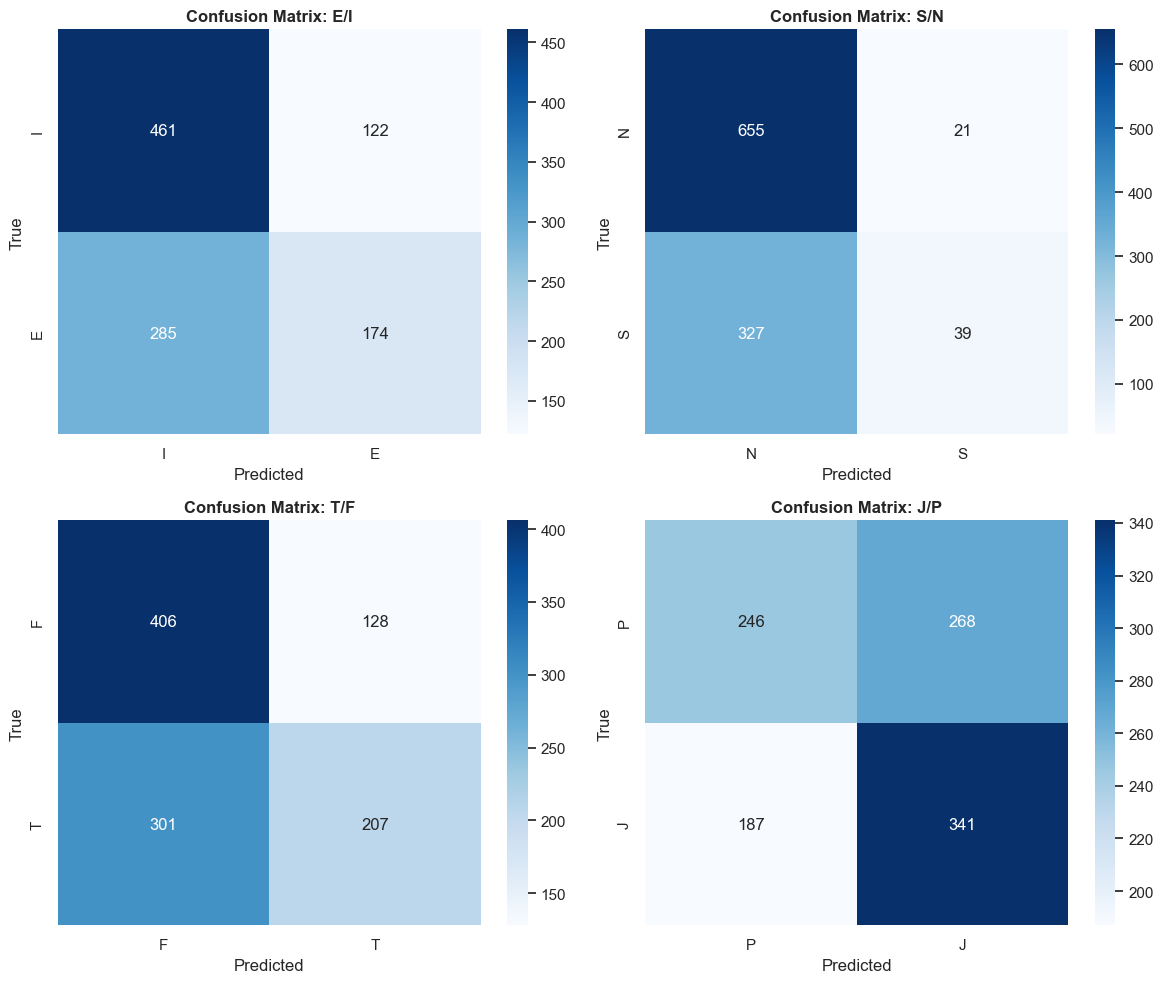

In [38]:
from sklearn.metrics import classification_report, confusion_matrix

results = [
    ("E/I", y_test_EI, preds_EI, ["I", "E"]),
    ("S/N", y_test_SN, preds_SN, ["N", "S"]),
    ("T/F", y_test_TF, preds_TF, ["F", "T"]),
    ("J/P", y_test_JP, preds_JP, ["P", "J"])
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, y_true, y_pred, labels) in zip(axes.flatten(), results):
    print(f"\n{'='*40}\nBÁO CÁO TRỤC {name}")
    print(classification_report(y_true, y_pred, target_names=labels, zero_division=0))
    
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=labels, yticklabels=labels)
    ax.set_title(f"Confusion Matrix: {name}", fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()


## 3. Phân tích Tầm quan trọng (Feature Importance)
Cùng xem chỉ số âm nhạc nào ảnh hưởng lớn nhất đến từng cục diện tính cách MBTI!


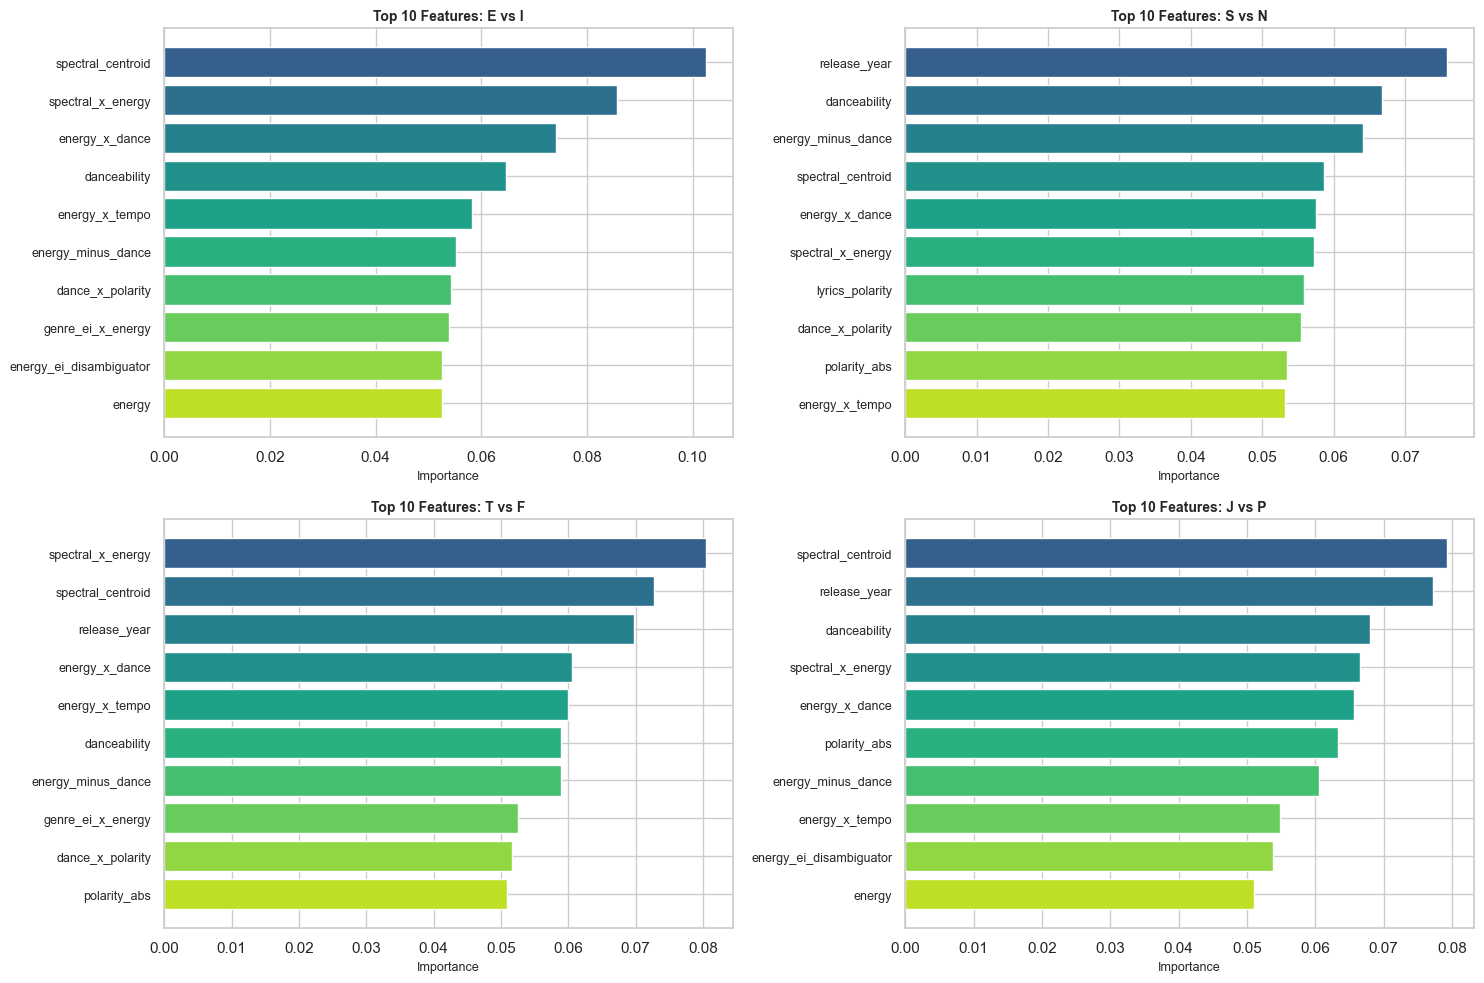

In [39]:
# Lấy Feature Importance từ BalancedRandomForestClassifier
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
models_list = [
    (model_EI, 'E vs I'),
    (model_SN, 'S vs N'),
    (model_TF, 'T vs F'),
    (model_JP, 'J vs P')
]

for ax, (m, title) in zip(axes.flatten(), models_list):
    importance = m.feature_importances_
    sorted_idx = np.argsort(importance)[::-1][:10]
    
    feat_names = np.array(features)[sorted_idx]
    feat_vals = importance[sorted_idx]
    
    bars = ax.barh(range(len(feat_names)), feat_vals, color=plt.cm.viridis(np.linspace(0.3, 0.9, len(feat_names))))
    ax.set_yticks(range(len(feat_names)))
    ax.set_yticklabels(feat_names, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Importance', fontsize=9)
    ax.set_title(f"Top 10 Features: {title}", fontweight='bold', fontsize=10)
    
plt.tight_layout()
plt.show()


## 4. Kết quả cuối
Đưa 1 bài hát vào, cả 4 Models sẽ xúm lại bỏ phiếu, tạo ra 1 loại tính cách cuối cùng.


In [40]:
def predict_full_mbti(test_features_1d):
    # Giả lập quy trình App Python: Truyền 1 mảng numpy chứa 10 features
    # Reshape về dạng 2D
    x_input = test_features_1d.values.reshape(1, -1)
    
    # Mô hình E/I
    pred_EI = model_EI.predict(scaler_EI.transform(x_input))[0]
    letter_1 = 'E' if pred_EI == 1 else 'I'
    
    # Mô hình S/N
    pred_SN = model_SN.predict(scaler_SN.transform(x_input))[0]
    letter_2 = 'S' if pred_SN == 1 else 'N'
    
    # Mô hình T/F
    pred_TF = model_TF.predict(scaler_TF.transform(x_input))[0]
    letter_3 = 'T' if pred_TF == 1 else 'F'
    
    # Mô hình J/P
    pred_JP = model_JP.predict(scaler_JP.transform(x_input))[0]
    letter_4 = 'J' if pred_JP == 1 else 'P'
    
    return f"{letter_1}{letter_2}{letter_3}{letter_4}"

# Test ngẫu nhiên 5 bài hát trong Data
sample_df = df.sample(5)
for idx, row in sample_df.iterrows():
    true_mbti = row['mbti_label']
    raw_features = row[features]
    predicted = predict_full_mbti(raw_features)
    
    icon = "✅" if predicted == true_mbti else "❌"
    print(f"{icon} Bài hát: {row['title']} | Thực tế: {true_mbti} | Model Đoán: {predicted}")


❌ Bài hát: Consume (feat. Goon Des Garcons) | Thực tế: ENTJ | Model Đoán: ENFP
❌ Bài hát: La Vie en Rose | Thực tế: INFP | Model Đoán: ENTJ
❌ Bài hát: Sue Me | Thực tế: ESTJ | Model Đoán: INTJ
❌ Bài hát: Halu | Thực tế: ISTJ | Model Đoán: INFJ
✅ Bài hát: Horizon | Thực tế: ENTJ | Model Đoán: ENTJ


LƯU LẠI AI VỪA TRAIN

In [41]:

joblib.dump(model_EI, 'model_EI.pkl')
joblib.dump(model_SN, 'model_SN.pkl')
joblib.dump(model_TF, 'model_TF.pkl')
joblib.dump(model_JP, 'model_JP.pkl')
joblib.dump(scaler_EI, 'scaler_common.pkl') 
print("Đã đóng gói xong toàn bộ model!")

Đã đóng gói xong toàn bộ model!
